# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Darpan)_

**Roll Number:** _(023-24-0237)_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_churn.csv")   # update path/filename if different


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_(The business wants to understand why customers leave (churn) so it can identify customers who are likely to leave and take action to retain them. The likely target variable is Churn, because it indicates whether a customer has left  Yes or No. )_

**Answer 2:**
##  5 useful Columns 
1 tenure — Customers with shorter tenure may be more likely to churn.
2 Contract — Month-to-month customers may churn more easily than long-term contract customers.
3  MonthlyCharges — Higher monthly charges may increase the chance of customers leaving.
4  InternetService — Different internet services may have different churn rates.
5  TechSupport — Customers without technical support may be less satisfied and more likely to churn.
# 2 useless Columns 
1 customerID : It is only a unique identifier and has no meaningful relationship with customer behavior.
2  gender :It may not provide much predictive value for churn and is not directly related to the customer's service experience.
  

**Answer 3:**
_(Are customers on month-to-month contracts significantly more likely to churn than customers on long-term contracts ?
Does a higher monthly charge or lack of services such as Tech Support/Online Security increase the probability of churn ?)

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [5]:
## Task 4 — dataset shape, column names, data types
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)



Shape:
(7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn             

In [6]:
# Task 5 — identify identifier columns / wrong data types
print(df.select_dtypes(include="object").columns)
##
for col in df.columns:
    if df[col].nunique() == len(df):
        print(col)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')
customerID


In [7]:
# Task 6 — unique values in 3 categorical columns


print("Contract:")
print(df["Contract"].unique())

print("\nInternetService:")
print(df["InternetService"].unique())

print("\nPaymentMethod:")
print(df["PaymentMethod"].unique())


Contract:
['Month-to-month' 'One year' 'Two year']

InternetService:
['DSL' 'Fiber optic' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [8]:
# Task 7 — missing values: count and percentage per column
df.isnull().mean() * 100


customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [9]:
# Task 8 — duplicate rows vs duplicate IDs
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate IDs:", df["customerID"].duplicated().sum())



Duplicate Rows: 0
Duplicate IDs: 0


In [10]:
# Task 9 — investigate a suspicious / invalid value


**Answer 7 (which missing-value problems need action, and why):**
_(Only TotalCharges needs action because 11 whitespace entries (" ") are masked as non-null strings, forcing the column into an object data type.
Replacing these whitespaces with 0.0 or NaN is required to convert the column to numeric data for analysis and model training)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_( They are different issues )_

**Answer 9 (suspicious value found and how):**
_()_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

Problem Decision Method UsedReason:  TotalCharges stored as text with whitespace strings (" ")Convert invalid whitespace entries to NaN and impute with 0.0pd.to_numeric(df['TotalCharges'], errors='coerce') and df['TotalCharges'].fillna(0.0)All 11 affected rows correspond to new accounts with tenure = 0 who have not completed a billing cycle yet; replacing with 0.0 accurately reflects their balance while converting the column to float64 for numerical analysis.

In [11]:
# Task 11 — apply your cleaning decisions here
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0.0)
print(df['TotalCharges'])


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64


In [12]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
# Verification Code
print("Missing values count:", df.isnull().sum().sum())
print("Duplicate rows count:", df.duplicated().sum())
print("Duplicate IDs count:", df['customerID'].duplicated().sum())
print("TotalCharges Dtype:", df['TotalCharges'].dtype)


Missing values count: 0
Duplicate rows count: 0
Duplicate IDs count: 0
TotalCharges Dtype: float64


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

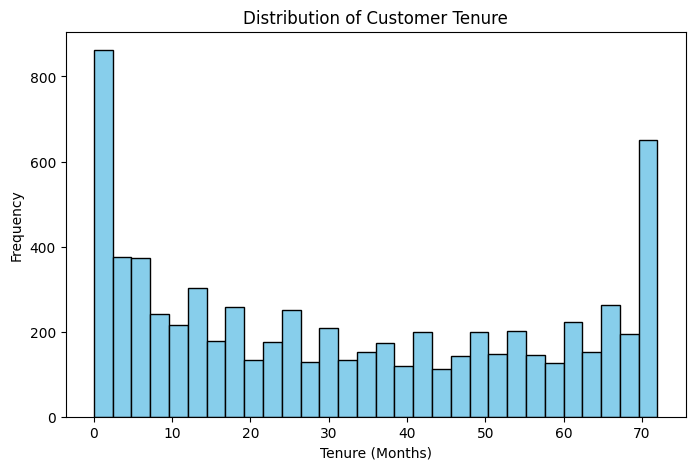

In [13]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize=(8, 5))
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.show()


**Observation:** _(Tenure (Numerical): High concentration at 1 month and 70+ months shows customers drop off immediately early on or become long-term loyalists.



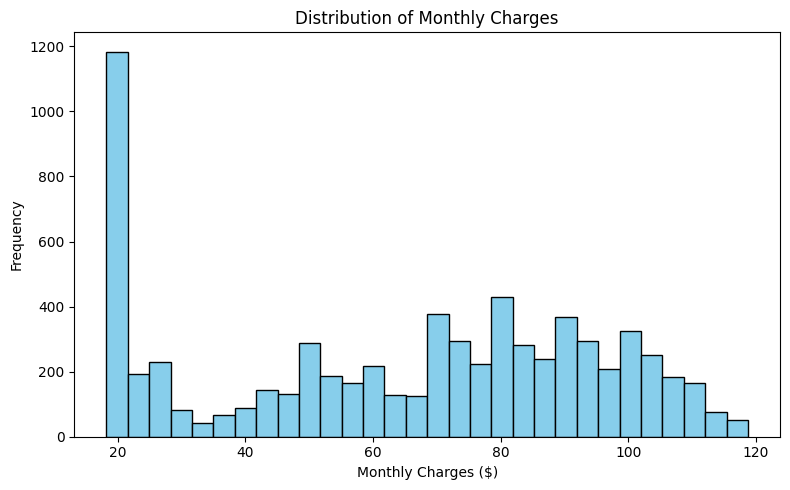

In [14]:
# Task 12 — numerical feature 2: distribution plot

plt.figure(figsize=(8, 5))
plt.hist(df['MonthlyCharges'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**Observation:**Monthly Charges (Numerical): A massive spike at $18–$25 reveals a large base on basic services, while higher charges ($70–$110) reflect premium fiber and bundled packages)

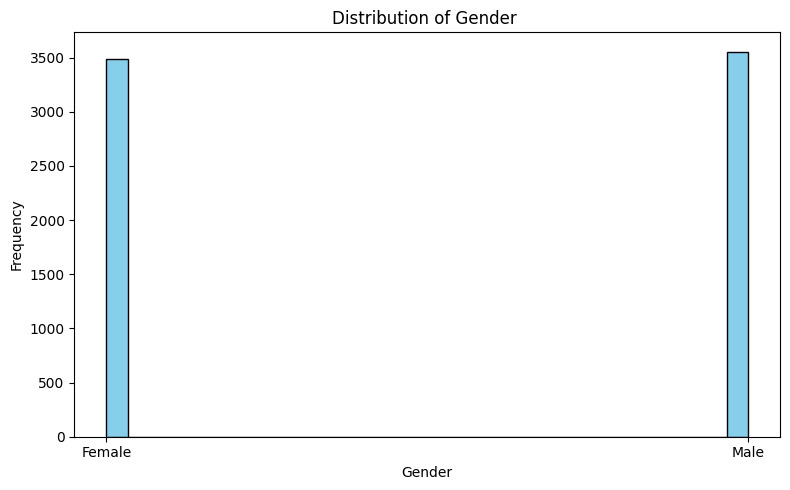

In [15]:
# Task 12 — categorical feature 1: distribution plot

plt.figure(figsize=(8, 5))
plt.hist(df['gender'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Gender ')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



**Observation:** _(From this char I can say that is male ansd female are equally balance . There is no imbalance in dataset)_

<function matplotlib.pyplot.show(close=None, block=None)>

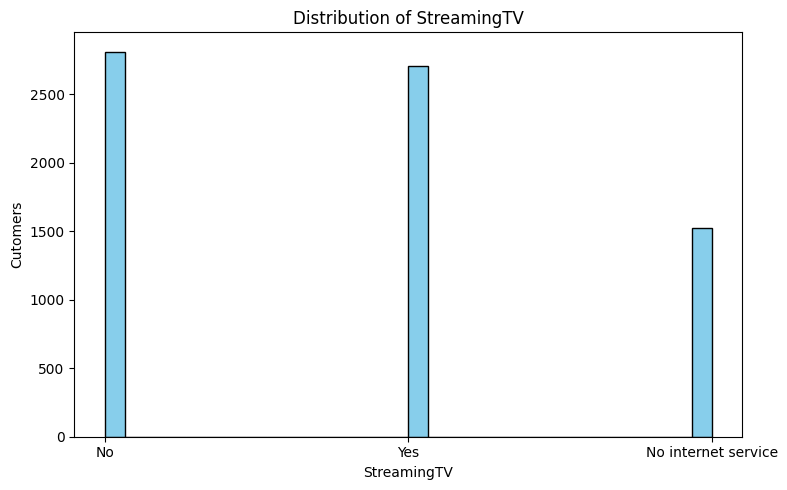

In [16]:
# Task 12 — categorical feature 2: distribution plot

plt.figure(figsize=(8, 5))
plt.hist(df["StreamingTV"], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of StreamingTV')
plt.xlabel('StreamingTV')
plt.ylabel('Cutomers')
plt.tight_layout()
plt.show

**Observation:**_(No and Yes Streaming TV has hight Customer as to compared No internet Service has fewer customer)_

**Answer 13 (outliers / skew and possible explanation):**
_(There is no outlier in StreamingTV the difference in categorical  frequencies is expected because not all customers have internet service or subscribe to streaming TV.)

---

In [17]:
# Task 14 — churn counts and percentages
print(df['Churn'].value_counts())
print(df["Churn"].value_counts(normalize = True)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_(The dataset is imbalance because 73.46% of cutomers didnot churn , while only 26.5% of the customer only churned )_

**Answer 15 (why imbalance might matter later):**
_(Imbalance matters later because a machine learning model can be biased toward majority class )_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [18]:
# Task 16 — categorical feature 1 vs Churn
pd.crosstab(df["gender"], df['Churn'], normalize='index')

Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


**Observation:** Churn rate is identical across genders 
**Evidence:** Femal : 26.9% churn (73.07% retained)
              Male : 26.1% churn (73.8% retained)
**Possible Explanation:** Gender is likely not a driver of churn in this dataset. Churn decisions in a telecom context are typically driven by service-related factors

In [19]:
# Task 16 — categorical feature 2 vs Churn
df.groupby('StreamingTV')['Churn'].value_counts()

StreamingTV          Churn
No                   No       1868
                     Yes       942
No internet service  No       1413
                     Yes       113
Yes                  No       1893
                     Yes       814
Name: count, dtype: int64

**Observation:** Customers with no internet service churn far less than those who do have internet — regardless of whether they subscribe to Stream
**Evidence:**No internet service: 113 churned / 1,526 total = 7.4% churn
No StreamingTV (has internet): 942 churned / 2,810 total  =33.5% churn
Yes StreamingTV (has internet): 814 churned / 2,707 total = 30.1% churn
**Possible Explanation:**Customers without internet service avoid the pain points (pricing, reliability, tech support) that drive churn, making them inherently more stable. Among internet users, having StreamingTV correlates with slightly lower churn, likely due to greater service engagement.

In [20]:
# Task 17 — numerical feature 1 vs Churn
df.groupby('tenure')['Churn'].value_counts()

tenure  Churn
0       No        11
1       Yes      380
        No       233
2       Yes      123
        No       115
                ... 
70      Yes       11
71      No       164
        Yes        6
72      No       356
        Yes        6
Name: count, Length: 145, dtype: int64

**Observation:** Customers who churn tend to have much shorter tenure than those who stay
**Evidence:** Retained customers average ~37.6 months tenure vs ~18 months for churned customers, with churned customers' median tenure at just 10 months.
**Possible Explanation:**Churn risk is highest early in the customer lifecycle, while customers who stay longer tend to become more locked in and less likely to leave.

In [21]:
# Task 17 — numerical feature 2 vs Churn
df.groupby("MonthlyCharges")["Churn"].value_counts()


MonthlyCharges  Churn
18.25           No       1
18.40           No       1
18.55           No       1
18.70           No       2
18.75           No       1
                        ..
118.20          No       1
118.35          Yes      1
118.60          No       2
118.65          No       1
118.75          No       1
Name: count, Length: 2370, dtype: int64

**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

In [22]:
# Task 18 — correlation matrix and heatmapcorr
corr = df.corr(numeric_only=True)
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


<Axes: >

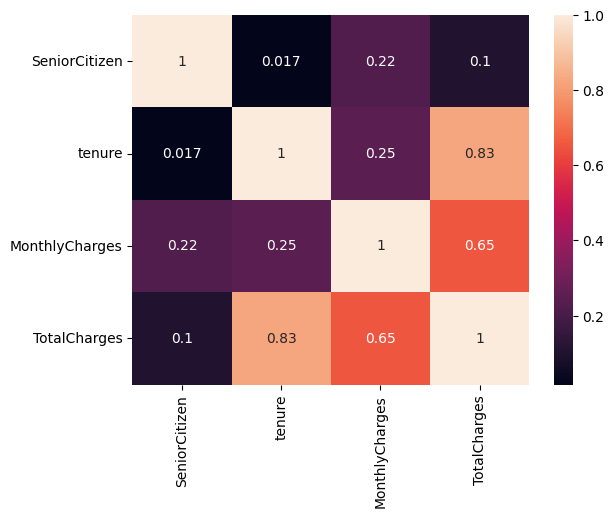

In [23]:
## heatmap 
sns.heatmap(corr,annot = True)

**Answer 18 (most correlated pairs):**
_(The most correlated pair is tenure & MonthlyCharges (r = 0.25), followed by SeniorCitizen & MonthlyCharges (r = 0.22); all correlations are weak overall.)_

**Answer 19 (correlation vs. causation; potential problems):**
_(The most correlated pair is tenure & MonthlyCharges (r = 0.25), followed by SeniorCitizen & MonthlyCharges (r = 0.22); all correlations are weak overall.)_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(customerID is the main suspect — it's a pure identifier with no predictive value and risks overfitting if used. TotalCharges is a secondary concern since it's largely derived from tenure × MonthlyCharges, adding redundancy rather than new information.)_

**Answer 21 (what would go wrong):**
_(If such a column were left in, the model would "cheat" by relying on information with no real predictive value or unavailable at prediction time, causing **data leakage**. It would look highly accurate during training/testing but perform poorly on real, new customers, since it learned shortcuts rather than genuine churn patterns.)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique per row, no predictive value; risks overfitting/memorization |
| gender | Categorical | Feature | Encode | Weak association with churn but keep for completeness; needs one-hot/label encoding |
| SeniorCitizen | Numerical (binary) | Feature | Keep | Already 0/1 encoded; usable as-is |
| Partner | Categorical | Feature | Encode | Yes/No; convert to binary |
| Dependents | Categorical | Feature | Encode | Yes/No; convert to binary |
| tenure | Numerical | Feature | Keep | Strong churn predictor; may benefit from scaling |
| PhoneService | Categorical | Feature | Encode | Yes/No; convert to binary |
| MultipleLines | Categorical | Feature | Encode | Has 3 categories including "No phone service"; one-hot encode |
| InternetService | Categorical | Feature | Encode | 3 categories (DSL/Fiber/No); one-hot encode |
| OnlineSecurity | Categorical | Feature | Encode | 3 categories incl. "No internet service"; one-hot encode |
| OnlineBackup | Categorical | Feature | Encode | Same pattern as OnlineSecurity; one-hot encode |
| DeviceProtection | Categorical | Feature | Encode | Same pattern; one-hot encode |
| TechSupport | Categorical | Feature | Encode | Same pattern; one-hot encode |
| StreamingTV | Categorical | Feature | Encode | Same pattern; one-hot encode |
| StreamingMovies | Categorical | Feature | Encode | Same pattern; one-hot encode |
| Contract | Categorical | Feature | Encode | Strong churn signal (month-to-month vs long-term); one-hot/ordinal encode |
| PaperlessBilling | Categorical | Feature | Encode | Yes/No; convert to binary |
| PaymentMethod | Categorical | Feature | Encode | 4 categories; one-hot encode |
| MonthlyCharges | Numerical | Feature | Keep | Meaningful churn signal; may benefit from scaling |
| TotalCharges | Numerical (stored as text) | Feature | Clean & convert | Fix data type (has blanks/spaces), convert to float; watch redundancy with tenure × MonthlyCharges |
| Churn | Categorical | Target | Encode | Convert Yes/No to 1/0 for modeling |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [24]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...



# 1. Drop pure identifier column (no predictive value, risks overfitting)
clean_df = clean_df.drop(columns=["customerID"])

# 2. Fix TotalCharges: stored as text with blank entries -> convert to numeric
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")
# The 11 missing values all correspond to tenure == 0 (brand-new customers who
# haven't been billed yet), so it's safe to fill them with 0.
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)

# 3. Encode target: Churn Yes/No -> 1/0
clean_df["Churn"] = clean_df["Churn"].map({"Yes": 1, "No": 0})

# 4. Encode simple binary Yes/No columns
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    clean_df[col] = clean_df[col].map({"Yes": 1, "No": 0})

# gender -> binary (Male=1, Female=0)
clean_df["gender"] = clean_df["gender"].map({"Male": 1, "Female": 0})

# 5. One-hot encode remaining multi-category columns (3+ categories)
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]
clean_df = pd.get_dummies(clean_df, columns=multi_cat_cols, drop_first=True)

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Saved clean_churn.csv with shape:", clean_df.shape)
# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


Saved clean_churn.csv with shape: (7043, 31)


In [27]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("Data info = : \n",clean_df.info())
print("\n")
print("Null values sum across coulmns :\n",clean_df.isnull().sum())
print("\n")
print("Duplicated values across columns : ",clean_df.duplicated().sum())

df.to_csv("clean_churn.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
Observation: Contract type is one of the strongest churn predictors.
Evidence: Month-to-month churns at 42.7% vs. 2.8% for Two-year contracts.
Interpretation: Contract length acts as a commitment/switching-cost mechanism — longer contracts lock in customers and reduce churn opportunity windows.

**Finding 2**
Observation: Tenure is strongly linked to churn — newer customers leave far more often.
Evidence: Churned customers average ~18 months tenure vs. ~37.6 months for retained customers.
Interpretation: Churn risk concentrates early in the customer lifecycle, likely due to onboarding friction or customers still evaluating the service

**Finding 3**
Observation: Fiber optic internet customers churn much more than DSL or no-internet customers.
Evidence: Fiber optic churns at 41.9% vs. 19.0% (DSL) and 7.4% (no internet).
Interpretation: Fiber optic likely carries higher price points and/or more reliability issues, or attracts a less loyal customer segment_

**Finding 4**
Observation: Higher MonthlyCharges are associated with higher churn.
Evidence: $65–95/month customers churn at 35.9% vs. 10.9% for $0–35/month customers.
Interpretation: Bigger bills increase price sensitivity and willingness to switch providers.

**Finding 5**
Observation: Demographic features like gender show almost no relationship with churn, unlike service/contract features.
Evidence: Female churn (26.9%) vs. Male churn (26.2%) — under 1 point difference.
Interpretation: Churn in this dataset is driven by service experience and contract structure, not customer demographics.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _(Most important data-quality issue: TotalCharges stored as text with 11 hidden whitespace-blank entries — invisible to standard isna() checks but would break numeric operations if unaddressed.)_
2. What was the most interesting pattern you discovered?
   _(The combination of contract type and tenure — month-to-month, low-tenure customers form a clear high-risk churn segment)_
3. Which feature seems most useful for predicting churn?
   _(Most useful feature for predicting churn: Contract, since it shows the largest spread in churn rate (2.8% to 42.7%) of any feature examined.)_
4. Which feature should probably not be used, and why?
   _(Feature that should probably not be used: customerID — a unique identifier with no predictive signal that risks overfitting.)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _(Preprocessing needed before modeling (conceptually): Convert TotalCharges to numeric and fill/handle missing values; encode categorical columns (binary + one-hot); drop customerID; scale numeric features; address redundancy between TotalCharges and tenure×MonthlyCharges.)_
6. What would you do next if you had another 3 hours?
   _(With another 3 hours: Explore interaction effects (e.g., Contract × tenure), check for outliers in charges, examine multicollinearity among one-hot encoded service columns, and build a baseline logistic regression model to get real feature-importance rankings.)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [26]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook